In [1]:
import glob
import numpy as np
from PIL import Image

import torch
from torch import nn, optim
from torchvision import transforms
from torchvision.utils import make_grid
from torch.utils.data import Dataset, DataLoader
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_colab = None

In [2]:
dataset_path = '/content/drive/MyDrive/Colorization-Of-B&W-Images/images'
use_colab = True


In [3]:
import os
from tqdm.notebook import tqdm
from pathlib import Path

if use_colab == True:
    path = dataset_path
else:
    path = "Your path to the dataset"
def images_upload(path):
    images=[]
    for root,subfolders,files in os.walk(path):
        for file in tqdm(files):
            filename=root+os.sep+file
            if filename.endswith('jpg') or filename.endswith('png'):
                images.append(filename)
    images = images[0:2000]
    # return  np.random.choice(images, 1000)
    return  np.array(images)
images=images_upload(path)
print(images.shape)
print(images)


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/2013 [00:00<?, ?it/s]

(2000,)
['/content/drive/MyDrive/Colorization-Of-B&W-Images/images/Image/gsun_0cd869dda6c0c51ded050ca04444cd93.jpg'
 '/content/drive/MyDrive/Colorization-Of-B&W-Images/images/Image/gsun_0d969c7821cd12fadd365b4e0bf830cb.jpg'
 '/content/drive/MyDrive/Colorization-Of-B&W-Images/images/Image/gsun_0d466306d242f097df28b0797e5023df.jpg'
 ...
 '/content/drive/MyDrive/Colorization-Of-B&W-Images/images/Image/gsun_0d3c16491751f8372bd3e7f92d39fc48.jpg'
 '/content/drive/MyDrive/Colorization-Of-B&W-Images/images/Image/gsun_0b4c0fd311b99fac006101411545ef9e.jpg'
 '/content/drive/MyDrive/Colorization-Of-B&W-Images/images/Image/gsun_0dbf82eef7563c1837f2d982c4efd50e.jpg']


In [4]:
SIZE = 128

import cv2
from skimage.color import rgb2lab, lab2rgb

def convert_image_labels(images):
    labels=[]
    for i in tqdm(images):
        i = cv2.imread(i)
        i=cv2.cvtColor(i, cv2.COLOR_BGR2RGB)
        res_i=cv2.resize(i,(SIZE,SIZE))
        del i
        labels.append(res_i)
    return labels


def convert_image_inputs(images):
    inputs=[]
    for z in tqdm(images):
        z = cv2.imread(z)
        z=cv2.cvtColor(z,  cv2.COLOR_BGR2GRAY)
        res_z=cv2.resize(z,(SIZE,SIZE))
        del z
        inputs.append(res_z)
    return inputs

labels=convert_image_labels(images)
inputs=convert_image_inputs(images)


  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

In [5]:
def convert_image_inputs(images):
    labels = []
    for image_path in images:
        img = cv2.imread(image_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            res_img = cv2.resize(img, (SIZE, SIZE))
            labels.append(res_img)
    return labels
labels=convert_image_labels(images)

  0%|          | 0/2000 [00:00<?, ?it/s]

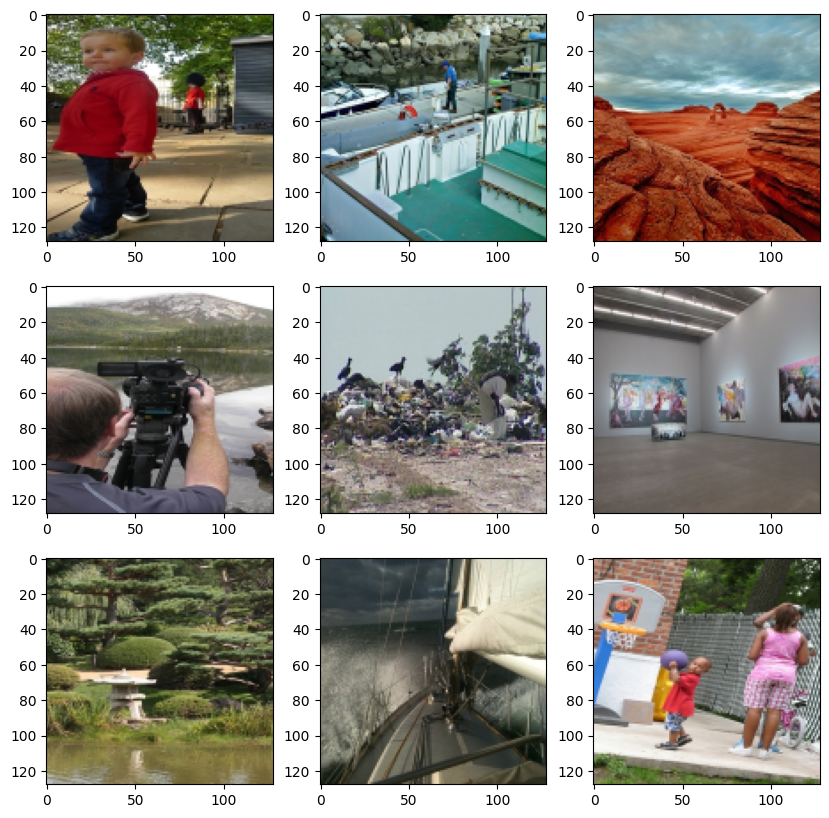

In [6]:
import matplotlib.pyplot as plt

def show_labels(labels):
    plt.figure(figsize=(10,10))
    for i in range(9):
        idx=np.random.randint(0,len(labels))
        plt.subplot(3,3,i+1)
        img=labels[idx]
        plt.imshow(img)

show_labels(labels)

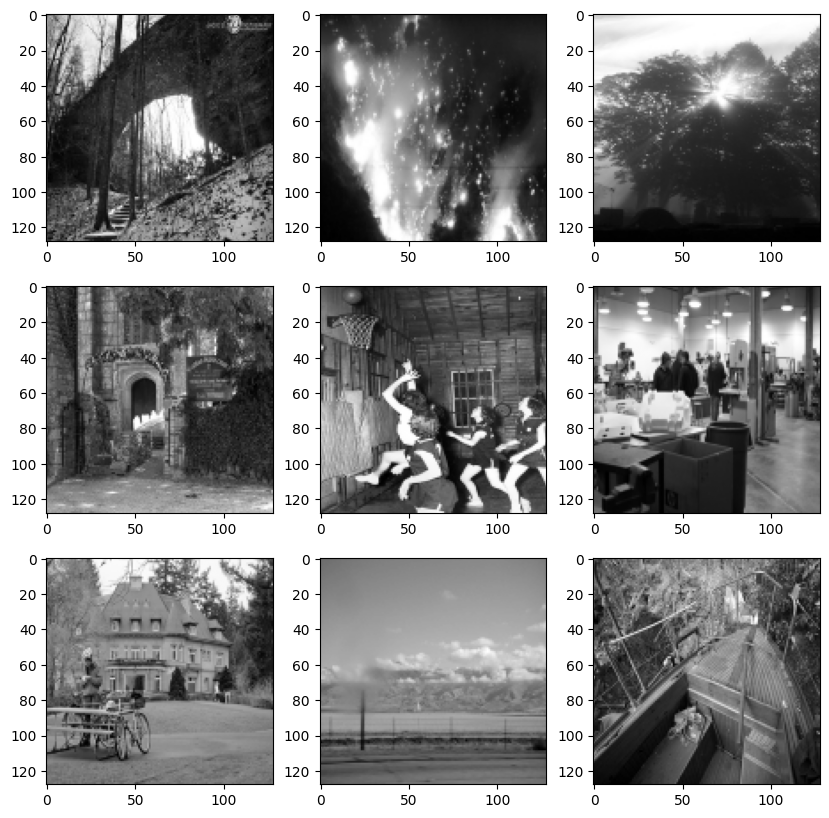

In [7]:
def show_input(inputs):
    plt.figure(figsize=(10,10))
    for i in range(9):
        idx=np.random.randint(0,len(inputs))
        plt.subplot(3,3,i+1)
        img=inputs[idx]
        plt.imshow(img,cmap='gray')
show_input(inputs)

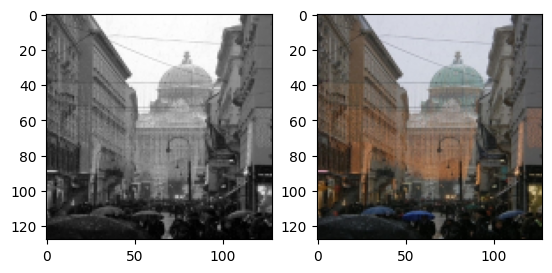

In [8]:
def images_compare(inputs,labels):
    idx_new=np.random.randint(0,len(labels))
    fig = plt.figure()
    ax1 = fig.add_subplot(1,2,1)
    ax1.imshow(inputs[idx_new],cmap='gray')
    ax2 = fig.add_subplot(1,2,2)
    ax2.imshow(labels[idx_new])
    plt.show()
images_compare(inputs,labels)

In [9]:
from sklearn.model_selection import train_test_split

def split_data(inputs,labels,test_size=0.2):
    labels=np.array(labels)
    inputs=np.array(inputs)
    x_train, x_test, y_train, y_test = train_test_split(inputs, labels, test_size=test_size)
    return x_train, x_test ,y_train,y_test

In [10]:
x_train,x_test ,y_train, y_test=split_data(inputs,labels,test_size=0.2)
x_train, x_test=x_train/255.0,x_test/255.0
y_train, y_test=y_train/255.0,y_test/255.0

In [11]:
import tensorflow as tf
from tensorflow.keras.layers import (
    BatchNormalization, Conv2D, Conv2DTranspose, Dense,
    Flatten, Dropout, UpSampling2D, Concatenate, ELU,
    Input, LeakyReLU, MaxPooling2D, Reshape, UpSampling2D)
from tensorflow.keras.models import Model
import tensorflow.keras.layers as tfl
from tensorflow.keras.optimizers import Adam

In [16]:
def build_generator(inputsize=(128, 128, 1)):
    input = Input(shape=inputsize)

    x = Conv2D(64, (3, 3), padding="same", kernel_initializer='he_normal', name='Conv1')(input)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)

    x = Conv2D(64, (3, 3), padding="same", kernel_initializer='he_normal', name='Conv2')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)

    x1 = Conv2D(64, (3, 3), padding="same", kernel_initializer='he_normal', name='Conv3')(x)
    x = BatchNormalization()(x1)
    x = LeakyReLU()(x)
    x = MaxPooling2D(pool_size=(2, 2), strides=(2, 2), name='MaxPool1')(x)

    x = Conv2D(128, (3, 3), padding="same", kernel_initializer='he_normal', name='Conv4')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)

    x = Conv2D(128, (3, 3), padding="same", kernel_initializer='he_normal', name='Conv5')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)

    x2 = Conv2D(128, (3, 3), padding="same", strides=(1, 1), kernel_initializer='he_normal', name='Conv6')(x)
    x = BatchNormalization()(x2)
    x = LeakyReLU()(x)
    x = MaxPooling2D(pool_size=(2, 2), name='MaxPool2')(x)

    x = Conv2D(256, (3, 3), padding="same", kernel_initializer='he_normal', name='Conv7')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)

    x = Conv2D(256, (3, 3), padding="same", kernel_initializer='he_normal', name='Conv8')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)

    x3 = Conv2D(256, (3, 3), padding="same", kernel_initializer='he_normal', name='Conv9')(x)
    x = BatchNormalization()(x3)
    x = LeakyReLU()(x)
    x = MaxPooling2D(pool_size=(2, 2), strides=(2, 2), name='MaxPool3')(x)

    x = Conv2D(512, (3, 3), padding="same", kernel_initializer='he_normal', name='Conv10')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)

    x = Conv2D(512, (3, 3), padding="same", kernel_initializer='he_normal', name='Conv11')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)

    x4 = Conv2D(512, (3, 3), padding="same", kernel_initializer='he_normal', name='Conv12')(x)
    x = BatchNormalization()(x4)
    x = LeakyReLU()(x)
    x = MaxPooling2D(pool_size=(2, 2), strides=(2, 2), name='MaxPool4')(x)

    x = Conv2D(1024, (3, 3), padding="same", name='Conv13')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)

    x = Conv2D(1024, (3, 3), padding="same", name='Conv14')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)

    x = Conv2D(1024, (3, 3), padding="same", kernel_initializer='he_normal', name='Conv15')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)

    x = Conv2DTranspose(512, (3, 3), strides=2, padding="same")(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)

    x = Concatenate()([x, x4])

    x = Conv2D(512, (3, 3), padding="same", kernel_initializer='he_normal', name='Conv16')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)

    x = Conv2D(512, (3, 3), padding="same", kernel_initializer='he_normal', name='Conv17')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)

    x = Conv2D(512, (3, 3), padding="same", kernel_initializer='he_normal', name='Conv18')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)

    x = Conv2DTranspose(256, (3, 3), strides=2, padding="same")(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)

    x = Concatenate()([x, x3])

    x = Conv2D(256, (3, 3), padding="same", kernel_initializer='he_normal', name='Conv19')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)

    x = Conv2D(256, (3, 3), padding="same", kernel_initializer='he_normal', name='Conv20')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)

    x = Conv2D(256, (3, 3), padding="same", kernel_initializer='he_normal', name='Conv21')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)

    x = Conv2DTranspose(128, (3, 3), strides=2, padding="same")(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)

    x = Concatenate()([x, x2])

    x = Conv2D(128, (3, 3), padding="same", kernel_initializer='he_normal', name='Conv22')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)

    x = Conv2D(128, (3, 3), padding="same", kernel_initializer='he_normal', name='Conv23')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)

    x = Conv2D(128, (3, 3), padding="same", kernel_initializer='he_normal', name='Conv24')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)

    x = Conv2DTranspose(64, (3, 3), strides=2, padding="same")(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)

    x = Concatenate()([x, x1])

    x = Conv2D(64, (3, 3), padding="same", kernel_initializer='he_normal', name='Conv25')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)

    x = Conv2D(64, (3, 3), padding="same", kernel_initializer='he_normal', name='Conv26')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)

    x = Conv2D(64, (3, 3), padding="same", kernel_initializer='he_normal', name='Conv27')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)

    outputs = Conv2D(3, (1, 1), padding="same", activation='tanh', name='Generator_Output')(x)

    generator_model = tf.keras.Model(inputs=input, outputs=outputs)
    generator_model.summary()
    return generator_model

In [17]:
generator = build_generator(inputsize=(SIZE, SIZE, 1))

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 256, 256,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv2 (Conv2D)      │ (None, 256, 256,  │     36,928 │ leaky_re_lu[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ Conv2[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv3 (Conv2D)      │ (None, 256, 256,  │     36,928 │ leaky_re_lu_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ Conv3[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MaxPool1            │ (None, 128, 128,  │          0 │ leaky_re_lu_2[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv4 (Conv2D)      │ (None, 128, 128,  │     73,856 │ MaxPool1[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ Conv4[0][0]       │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv5 (Conv2D)      │ (None, 128, 128,  │    147,584 │ leaky_re_lu_3[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ Conv5[0][0]       │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 128, 128,  │          0 │ batch_normalizat

 Total params: 50,258,499 (191.72 MB)

 Trainable params: 50,238,915 (191.65 MB)

 Non-trainable params: 19,584 (76.50 KB)

In [18]:
def build_discriminator():

    activation = tf.keras.layers.LeakyReLU(alpha=0.2)  # Sử dụng LeakyReLU như Model 1

    inputs = Input(shape=(SIZE, SIZE, 3))  # Điều chỉnh kích thước đầu vào để phù hợp với Model 1

    # Thay đổi các lớp Conv2D để có số lớp và kích thước đầu ra tương tự
    conv1 = Conv2D(64, kernel_size=(3, 3), strides=1, padding='same', kernel_initializer='he_normal')(inputs)
    conv1 = BatchNormalization()(conv1)
    conv1 = activation(conv1)
    conv1 = Conv2D(64, kernel_size=(3, 3), strides=1, padding='same', kernel_initializer='he_normal')(conv1)
    conv1 = BatchNormalization()(conv1)
    conv1 = activation(conv1)
    conv1 = MaxPooling2D()(conv1)

    conv2 = Conv2D(128, kernel_size=(3, 3), strides=1, padding='same', kernel_initializer='he_normal')(conv1)
    conv2 = BatchNormalization()(conv2)
    conv2 = activation(conv2)
    conv2 = Conv2D(128, kernel_size=(3, 3), strides=1, padding='same', kernel_initializer='he_normal')(conv2)
    conv2 = BatchNormalization()(conv2)
    conv2 = activation(conv2)
    conv2 = MaxPooling2D()(conv2)

    conv3 = Conv2D(256, kernel_size=(3, 3), strides=1, padding='same', kernel_initializer='he_normal')(conv2)
    conv3 = BatchNormalization()(conv3)
    conv3 = activation(conv3)
    conv3 = Conv2D(256, kernel_size=(3, 3), strides=1, padding='same', kernel_initializer='he_normal')(conv3)
    conv3 = BatchNormalization()(conv3)
    conv3 = activation(conv3)
    conv3 = MaxPooling2D()(conv3)

    conv4 = Conv2D(512, kernel_size=(3, 3), strides=1, padding='same', kernel_initializer='he_normal')(conv3)
    conv4 = BatchNormalization()(conv4)
    conv4 = activation(conv4)
    conv4 = Conv2D(512, kernel_size=(3, 3), strides=1, padding='same', kernel_initializer='he_normal')(conv4)
    conv4 = BatchNormalization()(conv4)
    conv4 = activation(conv4)
    conv4 = MaxPooling2D()(conv4)

    conv5 = Conv2D(1024, kernel_size=(3, 3), strides=1, padding='same', kernel_initializer='he_normal')(conv4)
    conv5 = BatchNormalization()(conv5)
    conv5 = activation(conv5)
    conv5 = Conv2D(1024, kernel_size=(3, 3), strides=1, padding='same', kernel_initializer='he_normal')(conv5)
    conv5 = BatchNormalization()(conv5)
    conv5 = activation(conv5)

    fully = Flatten()(conv5)
    fully = Dense(512)(fully)
    fully = BatchNormalization()(fully)
    fully = activation(fully)
    fully = Dense(128)(fully)
    fully = BatchNormalization()(fully)
    fully = activation(fully)
    fully = Dense(32)(fully)
    fully = BatchNormalization()(fully)
    fully = activation(fully)
    fully = Dense(1, activation='sigmoid')(fully)

    model = tf.keras.models.Model(inputs, fully)
    model.compile(loss='binary_crossentropy',optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5), metrics=['accuracy'])
    model.summary()
    return model

In [19]:
discriminator = build_discriminator()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_31      │ (None, 32)        │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ leaky_re_lu_31[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ leaky_re_lu_31[1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ leaky_re_lu_31[2… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ leaky_re_lu_31[3… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                 

 Total params: 153,149,825 (584.22 MB)

 Trainable params: 153,140,545 (584.18 MB)

 Non-trainable params: 9,280 (36.25 KB)

In [20]:
def build_gan(generator, discriminator):
    discriminator.trainable = False
    input = tf.keras.Input(shape=(SIZE, SIZE, 1))
    generated_image = generator(input)
    validity = discriminator(generated_image)
    gan = tf.keras.Model(inputs=input, outputs=[generated_image, validity])
    gan.compile(loss=['mse', 'binary_crossentropy'], loss_weights=[0.9999, 0.0001], optimizer='adam')
    gan.summary()
    return gan

gan = build_gan(generator, discriminator)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional (Functional)         │ (None, 256, 256, 3)    │    50,258,499 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_1 (Functional)       │ (None, 1)              │   153,149,825 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,408,324 (775.94 MB)

 Trainable params: 50,238,915 (191.65 MB)

 Non-trainable params: 153,169,409 (584.29 MB)

In [ ]:
import time

def train_gan(generator, discriminator, gan, x_train, y_train, epochs=1000, batch_size=64):
    batch_count = x_train.shape[0] // batch_size
    d_loss_list = []
    g_loss_list = []
    for e in range(epochs):
        start_time = time.time()  # Time start

        for _ in range(batch_count):
            idx = np.random.randint(0, x_train.shape[0], batch_size)
            real_images = y_train[idx]
            gray_images = x_train[idx]

            fake_images = generator.predict(gray_images)

            valid = np.ones((batch_size, 1))
            fake = np.zeros((batch_size, 1))

            d_loss_real = discriminator.train_on_batch(real_images, valid)
            d_loss_fake = discriminator.train_on_batch(fake_images, fake)
            d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

            valid = np.ones((batch_size, 1))

            g_loss = gan.train_on_batch(gray_images, [real_images, valid])

        end_time = time.time()  # Time end
        elapsed_time = end_time - start_time

        print(f"Epoch {e}/{epochs}, D Loss: {d_loss[0]}, G Loss: {g_loss[0]}, Time: {elapsed_time:.2f} seconds")

        # Save loss
        d_loss_list.append(d_loss[0])
        g_loss_list.append(g_loss[0])

        # Compute remaining time
        remaining_time = (epochs - e - 1) * elapsed_time
        hours = int(remaining_time // 3600)
        minutes = int((remaining_time % 3600) // 60)
        print(f"Estimated time remaining: {hours} hours {minutes} minutes")

    return d_loss_list, g_loss_list

In [ ]:
num_epochs = 60
d_loss_list, g_loss_list = train_gan(generator, discriminator, gan, x_train, y_train, epochs=num_epochs, batch_size=32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

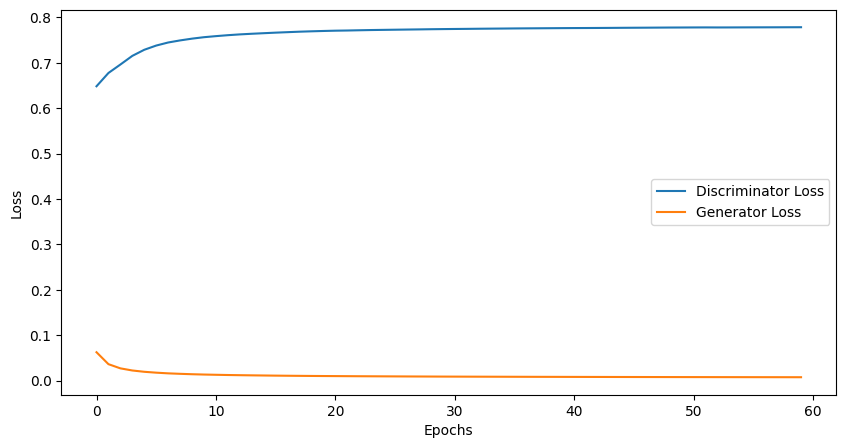

In [ ]:
import matplotlib.pyplot as plt

def plot_loss(d_loss, g_loss, num_epochs):
    plt.figure(figsize=(10, 5))
    plt.plot(range(num_epochs), d_loss, label="Discriminator Loss")
    plt.plot(range(num_epochs), g_loss, label="Generator Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_loss(d_loss_list, g_loss_list, num_epochs)

In [12]:
def generate_colored_images(generator, gray_images):
    colored_images = generator.predict(gray_images)
    return colored_images

In [ ]:
num_examples_to_generate = len(x_test)
generated_images = generate_colored_images(generator, x_test)

def result_compare(y_test, pred, x_test):
    num_samples = len(y_test)

    for idx in range(num_samples):
        fig = plt.figure()
        ax1 = fig.add_subplot(1, 3, 1)
        ax1.imshow(x_test[idx], cmap='gray')
        ax1.set_title('Input')
        ax2 = fig.add_subplot(1, 3, 2)
        ax2.imshow(pred[idx])
        ax2.set_title('Output')
        ax3 = fig.add_subplot(1, 3, 3)
        ax3.imshow(y_test[idx])
        ax3.set_title('Original image')
        plt.show()

result_compare(y_test, generated_images, x_test)

In [ ]:
from tensorflow.keras.models import load_model

generator.save('/content/drive/MyDrive/Colorization-Of-B&W-Images/generator_model.h5')


In [ ]:
import matplotlib.pyplot as plt

def plot_loss(d_loss, g_loss, num_epochs):
    plt.figure(figsize=(10, 5))
    plt.plot(range(num_epochs), d_loss, label="Discriminator Loss")
    plt.plot(range(num_epochs), g_loss, label="Generator Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_loss(d_loss_list, g_loss_list, num_epochs)

In [22]:
from skimage.metrics import peak_signal_noise_ratio as psnr
# from skimage.measure import compare_ssim as ssim

def calculate_metrics(colorized_image, ground_truth):
  """
  Calculates PSNR and SSIM between colorized image and ground truth.

  Args:
    colorized_image: The colorized image as a NumPy array.
    ground_truth: The ground truth (original color image) as a NumPy array.

  Returns:
    A dictionary containing PSNR and SSIM values.
  """
  psnr_value = psnr(ground_truth, colorized_image)
  # ssim_value = ssim(ground_truth, colorized_image, multichannel=True)
  return {"PSNR": psnr_value}


In [23]:
def generate_colored_images(generator, gray_images):
    colored_images = generator.predict(gray_images)
    return colored_images

In [24]:
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

num_examples_to_generate = len(x_test)
generated_images = generate_colored_images(model, x_test)

def result_compare(y_test, pred, x_test):
    num_samples = len(y_test)
    i = 0

    for idx in range(num_samples):
        fig = plt.figure()
        ax1 = fig.add_subplot(1, 3, 1)
        ax1.axis('off')
        ax1.imshow(x_test[idx], cmap='gray')
        # ax1.set_title('Input')
        ax2 = fig.add_subplot(1, 3, 2)
        ax2.axis('off')
        ax2.imshow(pred[idx])

        c_image = pred[idx]
        g_image = y_test[idx]

        # ax2.set_title('Output')
        ax3 = fig.add_subplot(1, 3, 3)
        ax3.axis('off')
        ax3.imshow(y_test[idx])
        # ax3.set_title('Original image')

        # print(calculate_metrics(c_image, g_image))
        fig.savefig(f'img{i}.png')
        plt.show()
        i+=1


result_compare(y_test, generated_images, x_test)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:

from tensorflow.keras.models import load_model

generator.save('/content/drive/MyDrive/Colorization-Of-B&W-Images/generator_model.keras')


In [ ]:

from tensorflow.keras.models import load_model

discriminator.save('/content/drive/MyDrive/Colorization-Of-B&W-Images/discriminator_model.keras')


In [ ]:

from tensorflow.keras.models import load_model

discriminator.save('/content/drive/MyDrive/Colorization-Of-B&W-Images/discriminator_model.h5')


In [ ]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/Colorization-of-B&W-Images/Model/generator_model2.keras')

In [28]:
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
model = load_model('/content/drive/MyDrive/Colorization-Of-B&W-Images/generator_model.keras')
num_examples_to_generate = len(x_test)
generated_images = generate_colored_images(model, x_test)

def result_compare(y_test, pred, x_test):
    num_samples = len(y_test)

    for idx in range(num_samples):
        fig = plt.figure()
        ax1 = fig.add_subplot(1, 3, 1)
        ax1.imshow(x_test[idx], cmap='gray')
        ax1.set_title('Input')
        ax2 = fig.add_subplot(1, 3, 2)
        ax2.imshow(pred[idx])

        c_image = pred[idx]
        g_image = y_test[idx]

        ax2.set_title('Output')
        ax3 = fig.add_subplot(1, 3, 3)
        ax3.imshow(y_test[idx])
        ax3.set_title('Original image')

        print(calculate_metrics(c_image, g_image))
        plt.show()

result_compare(y_test, generated_images, x_test)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:

import matplotlib.pyplot as plt
def calculate_metrics(colorized_image, ground_truth):
  """
  Calculates PSNR and SSIM between colorized image and ground truth.

  Args:
    colorized_image: The colorized image as a NumPy array.
    ground_truth: The ground truth (original color image) as a NumPy array.

  Returns:
    A dictionary containing PSNR and SSIM values.
  """
  psnr_value = psnr(ground_truth, colorized_image)
  ssim_value = ssim_score(ground_truth, colorized_image)
    # Reshape images to 2D for FID calculation
  ground_truth_2d = ground_truth.reshape(-1, ground_truth.shape[-1])
  colorized_image_2d = colorized_image.reshape(-1, colorized_image.shape[-1])

  fid_value = calculate_fid_score(ground_truth_2d, colorized_image_2d)
  return {"PSNR": psnr_value, "SSIM": ssim_value, "FID": fid_value}


def generate_colored_images(generator, gray_images):
    colored_images = generator.predict(gray_images)
    return colored_images

num_examples_to_generate = len(x_test)
generated_images = generate_colored_images(model, x_test)

def result_compare(y_test, pred, x_test):
    num_samples = len(y_test)

    for idx in range(num_samples):
        fig = plt.figure()
        ax1 = fig.add_subplot(1, 3, 1)
        ax1.imshow(x_test[idx], cmap='gray')
        ax1.set_title('Input')
        ax2 = fig.add_subplot(1, 3, 2)
        ax2.imshow(pred[idx])

        c_image = pred[idx]
        g_image = y_test[idx]

        ax2.set_title('Output')
        ax3 = fig.add_subplot(1, 3, 3)
        ax3.imshow(y_test[idx])
        ax3.set_title('Original image')

        metrics = calculate_metrics(c_image, g_image)
        print(f"PSNR: {metrics['PSNR']:.2f}, SSIM: {metrics['SSIM']:.2f}, FID: {metrics['FID']:.2f}")
        plt.show()

result_compare(y_test, generated_images, x_test)


Output hidden; open in https://colab.research.google.com to view.

In [27]:
import numpy as np
from skimage.color import rgb2lab, lab2rgb
from skimage.metrics import structural_similarity

def ssim_score(img1, img2):
    """
    Calculates the Structural Similarity Index (SSIM) between two images.

    Args:
        img1: The first image.
        img2: The second image.

    Returns:
        The SSIM score between the two images.
    """

    # Convert images to LAB color space
    img1_lab = rgb2lab(img1)
    img2_lab = rgb2lab(img2)

    # Extract luminance, a, and b channels
    l1, a1, b1 = img1_lab[..., 0], img1_lab[..., 1], img1_lab[..., 2]
    l2, a2, b2 = img2_lab[..., 0], img2_lab[..., 1], img2_lab[..., 2]

    # Calculate SSIM for each channel
    ssim_l = structural_similarity(l1, l2, data_range=100, channel_axis=-1)
    ssim_a = structural_similarity(a1, a2, data_range=100, channel_axis=-1)
    ssim_b = structural_similarity(b1, b2, data_range=100, channel_axis=-1)

    # Calculate weighted average of channel SSIMs
    ssim = (ssim_l * 0.5 + ssim_a * 0.3 + ssim_b * 0.2)

    return ssim


In [26]:
import numpy as np
from scipy.linalg import sqrtm

def calculate_fid_score(real_images, generated_images):
  """
  Calculates the Frechet Inception Distance (FID) score between two sets of images.

  Args:
    real_images: A NumPy array of real images.
    generated_images: A NumPy array of generated images.

  Returns:
    The FID score between the two sets of images.
  """

  # Calculate the mean and covariance matrices of the real and generated images.
  mu_real = np.mean(real_images, axis=0)
  mu_generated = np.mean(generated_images, axis=0)
  cov_real = np.cov(real_images, rowvar=False)
  cov_generated = np.cov(generated_images, rowvar=False)

  # Calculate the FID score.
  fid_score = np.linalg.norm(mu_real - mu_generated) ** 2 + np.trace(cov_real + cov_generated - 2 * sqrtm(cov_real @ cov_generated))

  return fid_score


In [25]:
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
def calculate_metrics(colorized_image, ground_truth):
  """
  Calculates PSNR and SSIM between colorized image and ground truth.

  Args:
    colorized_image: The colorized image as a NumPy array.
    ground_truth: The ground truth (original color image) as a NumPy array.

  Returns:
    A dictionary containing PSNR and SSIM values.
  """
  psnr_value = psnr(ground_truth, colorized_image)
  ssim_value = ssim_score(ground_truth, colorized_image)
    # Reshape images to 2D for FID calculation
  ground_truth_2d = ground_truth.reshape(-1, ground_truth.shape[-1])
  colorized_image_2d = colorized_image.reshape(-1, colorized_image.shape[-1])

  fid_value = calculate_fid_score(ground_truth_2d, colorized_image_2d)
  return {"PSNR": psnr_value, "SSIM": ssim_value, "FID": fid_value}


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


TypeError: Invalid shape (1, 128, 128) for image data

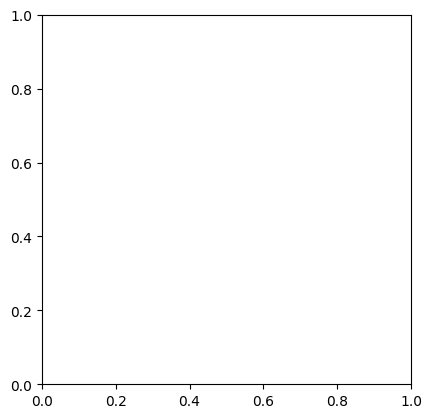

In [32]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import numpy as np
import cv2
SIZE = 128

model = load_model('/content/drive/MyDrive/Colorization-Of-B&W-Images/generator_model.keras')

def preprocess_image(image_path):
  """
  Loads an image from the given path and preprocesses it for prediction.

  Args:
    image_path: The path to the image file.

  Returns:
    A preprocessed image as a NumPy array.
  """

  # Load the image
  image = cv2.imread(image_path)

  # Resize the image
  image = cv2.resize(image, (SIZE, SIZE))

  # Convert the image to grayscale
  image_grayscale = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

  # Normalize the image
  image_grayscale = image_grayscale / 255.0

  # Add a dimension to the image
  image_grayscale = np.expand_dims(image_grayscale, axis=0)

  return image_grayscale

# Preprocess the image
image_path = '/content/drive/MyDrive/gray.jpeg'
image_preprocessed = preprocess_image(image_path)

# Make a prediction
prediction = model.predict(image_preprocessed)

# Show the prediction
plt.imshow(image_preprocessed)
plt.imshow(prediction[0])
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


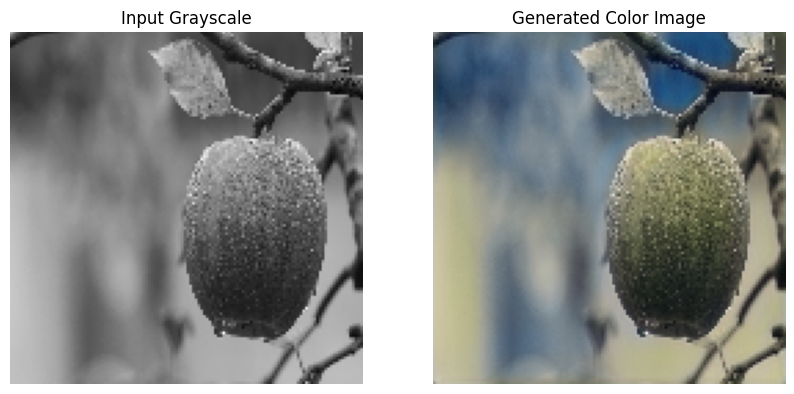

In [34]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import numpy as np
import cv2
SIZE = 128

model = load_model('/content/drive/MyDrive/Colorization-Of-B&W-Images/generator_model.keras')

def preprocess_image(image_path):
  """
  Loads an image from the given path and preprocesses it for prediction.

  Args:
    image_path: The path to the image file.

  Returns:
    A tuple containing:
      - image_for_model: A preprocessed image as a NumPy array (1, SIZE, SIZE, 1) for model input.
      - image_grayscale: The original 2D grayscale image (SIZE, SIZE) for display.
  """

  # Load the image
  image = cv2.imread(image_path)

  # Resize the image
  image = cv2.resize(image, (SIZE, SIZE))

  # Convert the image to grayscale
  image_grayscale = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

  # Normalize the image
  image_normalized = image_grayscale / 255.0

  # Add batch and channel dimensions for the model
  image_for_model = np.expand_dims(image_normalized, axis=0)   # (1, SIZE, SIZE)
  image_for_model = np.expand_dims(image_for_model, axis=-1)  # (1, SIZE, SIZE, 1)

  return image_for_model, image_grayscale

# Preprocess the image
image_path = '/content/drive/MyDrive/gray.jpeg'
image_for_model_input, original_grayscale_for_display = preprocess_image(image_path)

# Make a prediction
prediction = model.predict(image_for_model_input)

# Show the prediction
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(original_grayscale_for_display, cmap='gray')
plt.title('Input Grayscale')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(prediction[0])
plt.title('Generated Color Image')
plt.axis('off')
plt.show()
